# SOH Feature Engineering — BatPi Degradation Dataset

Extracts all 40+ features from the scientific feature catalog for every
`(session_timestamp, sub-cycle)` pair in `LOGBATTEST_Complete`, then links
each feature back to SOH using the same baseline logic as
`calculate_soh_history.py` (first-session capacity or nominal 18 Ah).

**File types used:**
| File | Columns | Rate |
|------|---------|------|
| `DegradationCycle_NN_discharge_DATE.csv` | Timestamp, Elapsed_s, Voltage, Current, Mode | ~1 Hz |
| `DegradationCycle_NN_charge_DATE.csv` | same + CC/CV mode | ~1 Hz |
| `DegradationCycle_NN_discharge_sensor_DATE.csv` | timestamp, voltage, current, temperature, humidity | ~14 Hz |
| `DegradationCycle_NN_charge_sensor_DATE.csv` | same | ~14 Hz |

In [3]:
# ── Imports & configuration ────────────────────────────────────────────────
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

# np.trapz was removed in NumPy 2.0; np.trapezoid is the replacement.
# hasattr avoids AttributeError entirely — safe on any NumPy version.
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_DIR = r"c:\Users\TPKam\Documents\BatPi_Download"
LOG_DIR  = os.path.join(BASE_DIR, "LOGBATTEST_Complete")

# ── Battery / test parameters ──────────────────────────────────────────────
NOMINAL_AH    = 18.0     # from calculate_soh_history.py
SOH_BASELINE  = "first"  # "first" = first session's Q_d; "nominal" = NOMINAL_AH
CYCLE_NUMS    = list(range(1, 11))   # sub-cycles 01–10

# ── Feature-extraction tuning ──────────────────────────────────────────────
DCIR_WINDOW_S = 3     # seconds after discharge start for R_DC estimate
ICA_SG_WIN    = 21    # Savitzky-Golay window for dQ/dV smoothing (odd)
ICA_SG_POLY   = 3
DT_CLIP_S     = 10    # max plausible sample interval [s]

## 1 · File discovery & loading

In [4]:
def find_sessions(log_dir: str) -> list:
    """Unique session timestamps that have ≥1 DegradationCycle discharge file."""
    pat = re.compile(
        r"^DegradationCycle_\d{2}_discharge_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})\.csv$"
    )
    sessions = {pat.match(fn).group(1)
                for fn in os.listdir(log_dir) if pat.match(fn)}
    return sorted(sessions)


def _load(path: str) -> pd.DataFrame:
    """Read CSV with lowercase column names; return empty DataFrame on failure."""
    if not os.path.exists(path):
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
        df.columns = [c.strip().lower() for c in df.columns]
        return df
    except Exception:
        return pd.DataFrame()


def load_discharge(sess, cn):
    return _load(os.path.join(LOG_DIR, f"DegradationCycle_{cn:02d}_discharge_{sess}.csv"))

def load_charge(sess, cn):
    return _load(os.path.join(LOG_DIR, f"DegradationCycle_{cn:02d}_charge_{sess}.csv"))

def load_discharge_sensor(sess, cn):
    return _load(os.path.join(LOG_DIR, f"DegradationCycle_{cn:02d}_discharge_sensor_{sess}.csv"))

def load_charge_sensor(sess, cn):
    return _load(os.path.join(LOG_DIR, f"DegradationCycle_{cn:02d}_charge_sensor_{sess}.csv"))


SESSIONS   = find_sessions(LOG_DIR)
FIRST_DATE = pd.Timestamp(SESSIONS[0][:10])
print(f"Found {len(SESSIONS)} sessions across "
      f"{len(set(s[:10] for s in SESSIONS))} calendar days")
for s in SESSIONS:
    n = sum(1 for cn in CYCLE_NUMS if os.path.exists(
        os.path.join(LOG_DIR, f"DegradationCycle_{cn:02d}_discharge_{s}.csv")))
    print(f"  {s}  →  {n} discharge cycles")

Found 21 sessions across 14 calendar days
  2025-11-27_13-19-58  →  1 discharge cycles
  2025-11-27_14-13-16  →  1 discharge cycles
  2025-12-09_14-46-34  →  1 discharge cycles
  2025-12-09_15-29-53  →  1 discharge cycles
  2025-12-09_15-40-42  →  1 discharge cycles
  2025-12-09_15-41-25  →  1 discharge cycles
  2025-12-09_15-42-35  →  1 discharge cycles
  2025-12-09_15-58-25  →  10 discharge cycles
  2026-01-27_20-58-50  →  10 discharge cycles
  2026-02-14_17-25-51  →  9 discharge cycles
  2026-02-16_14-42-38  →  1 discharge cycles
  2026-02-17_14-44-40  →  10 discharge cycles
  2026-02-20_02-46-22  →  10 discharge cycles
  2026-02-23_10-19-36  →  10 discharge cycles
  2026-02-24_21-28-36  →  10 discharge cycles
  2026-02-26_15-56-15  →  2 discharge cycles
  2026-03-06_13-23-46  →  8 discharge cycles
  2026-03-08_17-14-27  →  1 discharge cycles
  2026-03-08_17-35-53  →  10 discharge cycles
  2026-03-10_09-26-42  →  10 discharge cycles
  2026-03-12_22-02-01  →  1 discharge cycles


## 2 · Shared helpers

In [5]:
def _dt(elapsed_s: np.ndarray) -> np.ndarray:
    """Δt array clipped to [0, DT_CLIP_S]; first element = 0."""
    dt = np.diff(elapsed_s, prepend=elapsed_s[0])
    dt[0] = 0.0
    return np.clip(dt, 0.0, DT_CLIP_S)


def _v_at_q(v, q_cum, frac):
    """Voltage when cumulative capacity reaches `frac` × total."""
    q_tot = q_cum[-1]
    if q_tot <= 0:
        return np.nan
    idx = min(int(np.searchsorted(q_cum, frac * q_tot)), len(v) - 1)
    return float(v[idx])

## 3 · Discharge feature extraction

In [6]:
def extract_discharge(df: pd.DataFrame) -> dict:
    """
    Groups 1-5 from the feature catalog.
    Requires columns: elapsed_s, voltage, current
    """
    feat = {}
    if df.empty or not {"elapsed_s", "voltage", "current"}.issubset(df.columns):
        return feat

    v  = df["voltage"].to_numpy(float)
    i  = df["current"].to_numpy(float)
    t  = df["elapsed_s"].to_numpy(float)
    dt = _dt(t)

    # ── Group 2/3: capacity & energy ─────────────────────────────────────
    feat["Q_d"]  = float(np.abs(np.nansum(i * dt)) / 3600.0)
    feat["E_d"]  = float(np.abs(np.nansum(v * i * dt)) / 3600.0)
    feat["dt_d"] = float(t[-1])   # Δt_d — discharge duration [s]

    q_cum = np.cumsum(np.abs(i) * dt) / 3600.0  # monotonically increasing

    # ── Group 1: voltage differential features ────────────────────────────
    feat["V_start"] = float(v[0])
    feat["V_end"]   = float(v[-1])
    feat["dV_full"] = float(v[0] - v[-1])            # ΔV_full
    feat["V_mean"]  = float(np.nanmean(v))
    feat["A_Vt"]    = (float(_trapz(v, t) / (t[-1] - t[0]))
                       if t[-1] > t[0] else np.nan)   # mean V weighted by time

    feat["V_10"]    = _v_at_q(v, q_cum, 0.10)
    feat["V_50"]    = _v_at_q(v, q_cum, 0.50)
    feat["V_90"]    = _v_at_q(v, q_cum, 0.90)
    v20 = _v_at_q(v, q_cum, 0.20)
    v80 = _v_at_q(v, q_cum, 0.80)
    feat["dV_2080"] = (v20 - v80) if not (np.isnan(v20) or np.isnan(v80)) else np.nan

    # ── Group 4: DCIR at discharge onset ─────────────────────────────────
    # Row 0 = rest current; rows 1..N = under load
    # R_DC = (V_rest - V_load) / (I_load - I_rest)
    dcir_mask = t <= (t[0] + DCIR_WINDOW_S)
    if dcir_mask.sum() >= 2:
        v_rest  = float(v[0])
        v_load  = float(np.mean(v[dcir_mask][1:]))
        i_load  = float(np.mean(np.abs(i[dcir_mask][1:])))
        i_rest  = float(np.abs(i[0]))
        di      = i_load - i_rest
        if di > 0.5:                      # needs meaningful current step
            feat["R_DC"]  = float((v_rest - v_load) / di)
            feat["dV_IR"] = float(i_load * feat["R_DC"])
        else:
            feat["R_DC"] = feat["dV_IR"] = np.nan
    else:
        feat["R_DC"] = feat["dV_IR"] = np.nan

    # ── Group 5: ICA — dQ/dV peak (Dubarry & Liaw 2009) ──────────────────
    if feat["Q_d"] > 0.1 and len(v) > ICA_SG_WIN + 2:
        try:
            sort_i = np.argsort(v)              # ascending voltage
            v_s = v[sort_i];  q_s = q_cum[sort_i]
            v_u, uidx = np.unique(v_s, return_index=True)
            q_u = q_s[uidx]
            if len(v_u) > ICA_SG_WIN:
                dv_mean = float(np.mean(np.diff(v_u)))
                dqdv = savgol_filter(q_u, ICA_SG_WIN, ICA_SG_POLY,
                                     deriv=1, delta=dv_mean)
                pk = int(np.argmax(np.abs(dqdv)))
                feat["V_ICA"] = float(v_u[pk])
                feat["H_ICA"] = float(dqdv[pk])
                feat["A_ICA"] = float(_trapz(np.abs(dqdv), v_u))
            else:
                feat["V_ICA"] = feat["H_ICA"] = feat["A_ICA"] = np.nan
        except Exception:
            feat["V_ICA"] = feat["H_ICA"] = feat["A_ICA"] = np.nan
    else:
        feat["V_ICA"] = feat["H_ICA"] = feat["A_ICA"] = np.nan

    # ── Group 5: DVA — dV/dQ slope at 50 % SoC (Weng et al. 2013) ────────
    if feat["Q_d"] > 0.1:
        try:
            mid = (q_cum > 0.4 * feat["Q_d"]) & (q_cum < 0.6 * feat["Q_d"])
            feat["dVdQ_50"] = (float(np.polyfit(q_cum[mid], v[mid], 1)[0])
                               if mid.sum() >= 3 else np.nan)
        except Exception:
            feat["dVdQ_50"] = np.nan
    else:
        feat["dVdQ_50"] = np.nan

    return feat

## 4 · Charge feature extraction

In [7]:
def extract_charge(df: pd.DataFrame) -> dict:
    """
    Groups 1, 2, 3 from the feature catalog (charge side).
    Requires columns: elapsed_s, voltage, current  (+mode for CC/CV split)
    """
    feat = {}
    if df.empty or not {"elapsed_s", "voltage", "current"}.issubset(df.columns):
        return feat

    v  = df["voltage"].to_numpy(float)
    i  = df["current"].to_numpy(float)
    t  = df["elapsed_s"].to_numpy(float)
    dt = _dt(t)

    if "mode" in df.columns:
        mode = df["mode"].str.strip().str.upper().to_numpy()
        cc = mode == "CC"
        cv = mode == "CV"
    else:
        cc = np.ones(len(v), bool)
        cv = np.zeros(len(v), bool)

    # ── Group 2/3: charge capacity & energy ──────────────────────────────
    pos = i > 0.1
    feat["Q_c"]  = float(np.nansum(i[pos] * dt[pos]) / 3600.0) if pos.any() else np.nan
    feat["E_c"]  = float(np.nansum(v * np.abs(i) * dt) / 3600.0)
    feat["dt_c"] = float(t[-1])

    # ── Group 3: CC / CV durations ────────────────────────────────────────
    feat["dt_CC"] = float(np.nansum(dt[cc])) if cc.any() else np.nan
    feat["dt_CV"] = float(np.nansum(dt[cv])) if cv.any() else np.nan
    tot = (feat.get("dt_CC") or 0) + (feat.get("dt_CV") or 0)
    feat["f_t_CV"] = feat["dt_CV"] / tot if tot > 0 else np.nan

    # ── Group 3: CC→CV transition (Severson et al. 2019) ─────────────────
    cv_idx = np.where(cv)[0]
    if len(cv_idx):
        ti = cv_idx[0]
        feat["t_abs"] = float(t[ti])   # time to absorption voltage
        feat["V_abs"] = float(v[ti])
    else:
        feat["t_abs"] = feat["dt_CC"]
        feat["V_abs"] = float(v[-1]) if len(v) else np.nan

    # ── Group 2: CV capacity fraction ─────────────────────────────────────
    q_cv = float(np.nansum(i[cv] * dt[cv]) / 3600.0) if cv.any() else 0.0
    feat["Q_CV"]   = q_cv
    q_c = feat.get("Q_c") or 0
    feat["f_Q_CV"] = q_cv / q_c if q_c > 0 else np.nan

    # ── Group 1: CC voltage rise rate (dV/dt during CC) ───────────────────
    if cc.sum() >= 5:
        try:
            feat["dVdt_CC"] = float(np.polyfit(t[cc], v[cc], 1)[0])  # [V/s]
        except Exception:
            feat["dVdt_CC"] = np.nan
    else:
        feat["dVdt_CC"] = np.nan

    # ── Group 1: charge voltage swing ────────────────────────────────────
    feat["V0_charge"] = float(v[0])
    v_abs = feat.get("V_abs")
    feat["dV_CC"] = (float(v_abs - v[0])
                     if (v_abs is not None and not np.isnan(v_abs)) else np.nan)

    # ── CV tail current ───────────────────────────────────────────────────
    feat["I_tail"] = float(i[cv][-1]) if cv.any() else np.nan

    return feat

## 5 · Thermal feature extraction (sensor files)

In [8]:
def extract_thermal(df_ds: pd.DataFrame, df_cs: pd.DataFrame) -> dict:
    """
    Group 6 (thermal) + Group 7 (voltage ripple) from sensor files.
    df_ds = discharge sensor, df_cs = charge sensor.
    """
    feat = {}

    def _temp_stats(df, pfx):
        if df.empty or "temperature" not in df.columns:
            return
        T = df["temperature"].to_numpy(float)
        feat[f"T_start_{pfx}"] = float(T[0])
        feat[f"T_end_{pfx}"]   = float(T[-1])
        feat[f"dT_{pfx}"]      = float(T[-1] - T[0])    # ΔT — temp rise
        feat[f"T_max_{pfx}"]   = float(np.nanmax(T))
        feat[f"T_mean_{pfx}"]  = float(np.nanmean(T))
        if "humidity" in df.columns:
            feat[f"hum_{pfx}"] = float(df["humidity"].mean())

    _temp_stats(df_ds, "d")
    _temp_stats(df_cs, "c")

    # ── Group 6: thermal resistance R_th = ΔT_d / P_avg ──────────────────
    # Panchal et al. 2017: R_th increases with R_DC growth
    if (not df_ds.empty
            and {"voltage", "current"}.issubset(df_ds.columns)
            and "dT_d" in feat):
        v_s = df_ds["voltage"].to_numpy(float)
        i_s = df_ds["current"].to_numpy(float)
        p_avg = float(np.nanmean(np.abs(v_s * i_s)))
        feat["R_th"] = float(feat["dT_d"] / p_avg) if p_avg > 0 else np.nan
    else:
        feat["R_th"] = np.nan

    # ── Group 6: charge/discharge thermal asymmetry ────────────────────────
    dT_d = feat.get("dT_d", np.nan)
    dT_c = feat.get("dT_c", np.nan)
    feat["ddT"] = (float(dT_c - dT_d)
                   if not (np.isnan(dT_d) or np.isnan(dT_c)) else np.nan)

    # ── Group 7: voltage ripple std (high-freq sensor signal) ────────────
    if not df_ds.empty and "voltage" in df_ds.columns and len(df_ds) > 20:
        feat["V_ripple"] = float(
            df_ds["voltage"].rolling(20, min_periods=5).std().mean()
        )
    else:
        feat["V_ripple"] = np.nan

    return feat

## 6 · SOH calculation — aligned with `calculate_soh_history.py`

In [9]:
def compute_soh(sessions: list, cycle_nums: list,
                baseline: str = SOH_BASELINE,
                nominal_ah: float = NOMINAL_AH) -> pd.DataFrame:
    """
    Compute SOH for every (session_ts, cycle_n) pair.

    Matches calculate_soh_history.py logic:
      baseline='first'   → SOH = Q_d / Q_d_of_first_valid_session  (per cycle number)
      baseline='nominal' → SOH = Q_d / NOMINAL_AH

    Also always stores SOH_nominal for absolute reference.
    """
    records = []
    for sess in sessions:
        for cn in cycle_nums:
            df_d = load_discharge(sess, cn)
            if df_d.empty:
                continue
            fd = extract_discharge(df_d)
            q = fd.get("Q_d", np.nan)
            if np.isnan(q) or q <= 0:
                continue
            records.append({"session_ts": sess,
                             "cycle_n": cn, "Q_d": q})

    df = (pd.DataFrame(records)
            .sort_values(["cycle_n", "session_ts"])
            .reset_index(drop=True))

    if df.empty:
        return df

    if baseline == "nominal":
        df["SOH"] = df["Q_d"] / nominal_ah
    else:
        # Per-cycle-number: first session's Q_d = 100 % reference
        baselines = df.groupby("cycle_n")["Q_d"].first()
        df["SOH"] = df.apply(
            lambda r: r["Q_d"] / baselines[r["cycle_n"]], axis=1)

    df["SOH_nominal"] = df["Q_d"] / nominal_ah
    return df


soh_df = compute_soh(SESSIONS, CYCLE_NUMS)
print(f"SOH table: {len(soh_df)} records  |  "
      f"SOH range: {soh_df['SOH'].min():.3f} – {soh_df['SOH'].max():.3f}")
soh_df.head(10)

SOH table: 109 records  |  SOH range: 0.001 – 45.818


,session_ts,cycle_n,Q_d,SOH,SOH_nominal
0,2025-11-27_13-19-58,1,0.315444,1.000000,0.017525
1,2025-11-27_14-13-16,1,0.015151,0.048031,0.000842
2,2025-12-09_14-46-34,1,1.249169,3.960032,0.069398
3,2025-12-09_15-29-53,1,1.179598,3.739481,0.065533
4,2025-12-09_15-40-42,1,0.025224,0.079962,0.001401
5,2025-12-09_15-41-25,1,0.050449,0.159929,0.002803
6,2025-12-09_15-42-35,1,1.924298,6.100278,0.106905
7,2025-12-09_15-58-25,1,0.406473,1.288573,0.022582
8,2026-01-27_20-58-50,1,8.170630,25.901975,0.453924
9,2026-02-14_17-25-51,1,14.453072,45.818144,0.802948


## 7 · Build full feature DataFrame

In [10]:
rows = []
for sess in SESSIONS:
    for cn in CYCLE_NUMS:
        df_d  = load_discharge(sess, cn)
        if df_d.empty:
            continue
        df_c  = load_charge(sess, cn)
        df_ds = load_discharge_sensor(sess, cn)
        df_cs = load_charge_sensor(sess, cn)

        fd = extract_discharge(df_d)
        fc = extract_charge(df_c)
        ft = extract_thermal(df_ds, df_cs)

        # ── Cross-phase efficiency (Group 2) ──────────────────────────────
        q_d = fd.get("Q_d", np.nan);  q_c = fc.get("Q_c", np.nan)
        e_d = fd.get("E_d", np.nan);  e_c = fc.get("E_c", np.nan)
        fc["eta_C"] = (q_d / q_c
                       if (not np.isnan(q_d) and q_c and q_c > 0) else np.nan)
        fc["eta_E"] = (e_d / e_c
                       if (not np.isnan(e_d) and e_c and e_c > 0) else np.nan)

        rows.append({
            "session_ts":   sess,
            "session_date": pd.Timestamp(sess[:10]),
            "t_cal":        (pd.Timestamp(sess[:10]) - FIRST_DATE).days,
            "cycle_n":      cn,
            **fd, **fc, **ft,
        })

feat_df = (pd.DataFrame(rows)
             .sort_values(["cycle_n", "session_ts"])
             .reset_index(drop=True))
print(f"Feature DataFrame: {len(feat_df)} rows × {len(feat_df.columns)} columns")

Feature DataFrame: 109 rows × 53 columns


## 8 · Merge SOH + add temporal features

In [11]:
merged = feat_df.merge(
    soh_df[["session_ts", "cycle_n", "SOH", "SOH_nominal"]],
    on=["session_ts", "cycle_n"], how="left"
)

# ── Group 8: cumulative Ah throughput ─────────────────────────────────────
# Accumulate Q_d in chronological order across all (session, cycle) pairs
chrono = merged.sort_values(["session_ts", "cycle_n"]).copy()
chrono["cumQ"] = chrono["Q_d"].cumsum()
merged = merged.merge(chrono[["session_ts", "cycle_n", "cumQ"]],
                      on=["session_ts", "cycle_n"], how="left")

display(merged[["session_ts", "cycle_n", "Q_d", "SOH", "SOH_nominal",
                "R_DC", "dT_d", "eta_C", "f_t_CV", "V_ICA"]].head(20))

,session_ts,cycle_n,Q_d,SOH,SOH_nominal,R_DC,dT_d,eta_C,f_t_CV,V_ICA
0,2025-11-27_13-19-58,1,0.315444,1.000000,0.017525,0.050527,NaN,46.064476,NaN,11.5099
1,2025-11-27_14-13-16,1,0.015151,0.048031,0.000842,NaN,NaN,1.501059,NaN,NaN
2,2025-12-09_14-46-34,1,1.249169,3.960032,0.069398,0.057867,NaN,0.403770,NaN,11.2265
3,2025-12-09_15-29-53,1,1.179598,3.739481,0.065533,0.047253,0.5,NaN,NaN,11.7683
4,2025-12-09_15-40-42,1,0.025224,0.079962,0.001401,0.044028,0.0,NaN,NaN,NaN
5,2025-12-09_15-41-25,1,0.050449,0.159929,0.002803,0.043090,0.1,NaN,NaN,NaN
6,2025-12-09_15-42-35,1,1.924298,6.100278,0.106905,0.044020,0.8,9.734273,NaN,11.5849
7,2025-12-09_15-58-25,1,0.406473,1.288573,0.022582,NaN,0.0,0.031930,0.471301,10.8598
8,2026-01-27_20-58-50,1,8.170630,25.901975,0.453924,0.053278,0.4,0.885403,0.573063,11.9933
9,2026-02-14_17-25-51,1,14.453072,45.818144,0.802948,0.047267,0.4,1.074310,0.350270,12.2850


## 9 · Feature–SOH correlation table

In [12]:
# Feature catalogue with descriptions
FEAT_META = {
    # Group 1 – voltage differential
    "V_start":   ("G1", "V_start — OCV before discharge [V]"),
    "V_end":     ("G1", "V_end — terminal voltage [V]"),
    "dV_full":   ("G1", "ΔV_full — total voltage drop [V]"),
    "V_10":      ("G1", "V_10 — voltage at 10 % capacity [V]"),
    "V_50":      ("G1", "V_50 — voltage at 50 % capacity [V]"),
    "V_90":      ("G1", "V_90 — voltage at 90 % capacity [V]"),
    "dV_2080":   ("G1", "ΔV_2080 — voltage window 20–80 % SoC [V]"),
    "A_Vt":      ("G1", "A_Vt — time-averaged voltage [V]"),
    "dV_CC":     ("G1", "ΔV_CC — charge CC voltage rise [V]"),
    "dVdt_CC":   ("G1", "dV/dt_CC — CC voltage rise rate [V/s]"),
    # Group 2/3 – capacity, energy, time
    "Q_d":       ("G2", "Q_d — discharge capacity [Ah]"),
    "E_d":       ("G2", "E_d — discharge energy [Wh]"),
    "dt_d":      ("G3", "Δt_d — discharge duration [s]"),
    "Q_c":       ("G2", "Q_c — charge capacity [Ah]"),
    "E_c":       ("G2", "E_c — charge energy [Wh]"),
    "f_Q_CV":    ("G2", "f_Q_CV — CV capacity fraction"),
    "eta_C":     ("G2", "η_C — coulombic efficiency"),
    "eta_E":     ("G2", "η_E — energy efficiency"),
    "dt_CC":     ("G3", "Δt_CC — CC charge duration [s]"),
    "dt_CV":     ("G3", "Δt_CV — CV charge duration [s]"),
    "f_t_CV":    ("G3", "f_t_CV — CV time fraction"),
    "t_abs":     ("G3", "t_abs — time to absorption voltage [s]"),
    # Group 4 – resistance
    "R_DC":      ("G4", "R_DC — DC internal resistance [Ω]"),
    "dV_IR":     ("G4", "ΔV_IR — ohmic voltage drop [V]"),
    # Group 5 – ICA / DVA
    "V_ICA":     ("G5", "V_ICA — ICA peak voltage [V]"),
    "H_ICA":     ("G5", "H_ICA — ICA peak height [Ah/V]"),
    "A_ICA":     ("G5", "A_ICA — ICA curve area"),
    "dVdQ_50":   ("G5", "dV/dQ_50 — DVA slope at 50 % SoC [V/Ah]"),
    # Group 6 – thermal
    "dT_d":      ("G6", "ΔT_d — temp rise discharge [°C]"),
    "dT_c":      ("G6", "ΔT_c — temp rise charge [°C]"),
    "T_max_d":   ("G6", "T_max_d — peak temp discharge [°C]"),
    "T_mean_d":  ("G6", "T_mean_d — mean temp discharge [°C]"),
    "R_th":      ("G6", "R_th — thermal resistance [°C/W]"),
    "ddT":       ("G6", "ΔΔT — thermal asymmetry charge–discharge [°C]"),
    # Group 7 – high-freq
    "V_ripple":  ("G7", "σ_V — voltage ripple std"),
    # Group 8 – temporal
    "t_cal":     ("G8", "t_cal — calendar age [days]"),
    "cumQ":      ("G8", "ΣQ — cumulative Ah throughput [Ah]"),
}

feat_cols = [c for c in FEAT_META if c in merged.columns]

corr_rows = []
for col in feat_cols:
    sub = merged[["SOH", col]].dropna()
    if len(sub) < 5:
        continue
    pr, pp = pearsonr(sub[col], sub["SOH"])
    sr, sp = spearmanr(sub[col], sub["SOH"])
    grp, desc = FEAT_META[col]
    corr_rows.append({
        "Group":       grp,
        "Feature":     col,
        "Description": desc,
        "Pearson r":   round(pr, 3),
        "Pearson p":   round(pp, 4),
        "Spearman r":  round(sr, 3),
        "Spearman p":  round(sp, 4),
        "abs_r":       abs(round(pr, 3)),
    })

corr_df = (pd.DataFrame(corr_rows)
             .sort_values("abs_r", ascending=False)
             .drop(columns=["abs_r"])
             .reset_index(drop=True))
corr_df.index += 1
print("Feature–SOH correlation (sorted by |Pearson r|):")
display(corr_df)

Feature–SOH correlation (sorted by |Pearson r|):


,Group,Feature,Description,Pearson r,Pearson p,Spearman r,Spearman p
1,G6,dT_c,ΔT_c — temp rise charge [°C],0.474,0.0000,0.689,0.0000
2,G4,dV_IR,ΔV_IR — ohmic voltage drop [V],-0.408,0.0000,-0.632,0.0000
3,G6,T_mean_d,T_mean_d — mean temp discharge [°C],-0.403,0.0000,-0.510,0.0000
4,G4,R_DC,R_DC — DC internal resistance [Ω],-0.382,0.0001,-0.437,0.0000
5,G6,T_max_d,T_max_d — peak temp discharge [°C],-0.364,0.0001,-0.445,0.0000
6,G6,dT_d,ΔT_d — temp rise discharge [°C],0.327,0.0006,-0.280,0.0036
7,G3,f_t_CV,f_t_CV — CV time fraction,-0.287,0.0042,0.195,0.0545
8,G6,R_th,R_th — thermal resistance [°C/W],0.286,0.0030,-0.253,0.0090
9,G5,A_ICA,A_ICA — ICA curve area,0.277,0.0044,0.673,0.0000
10,G1,dV_2080,ΔV_2080 — voltage window 20–80 % SoC [V],0.268,0.0048,0.720,0.0000


## 10 · Top features vs SOH — scatter plots

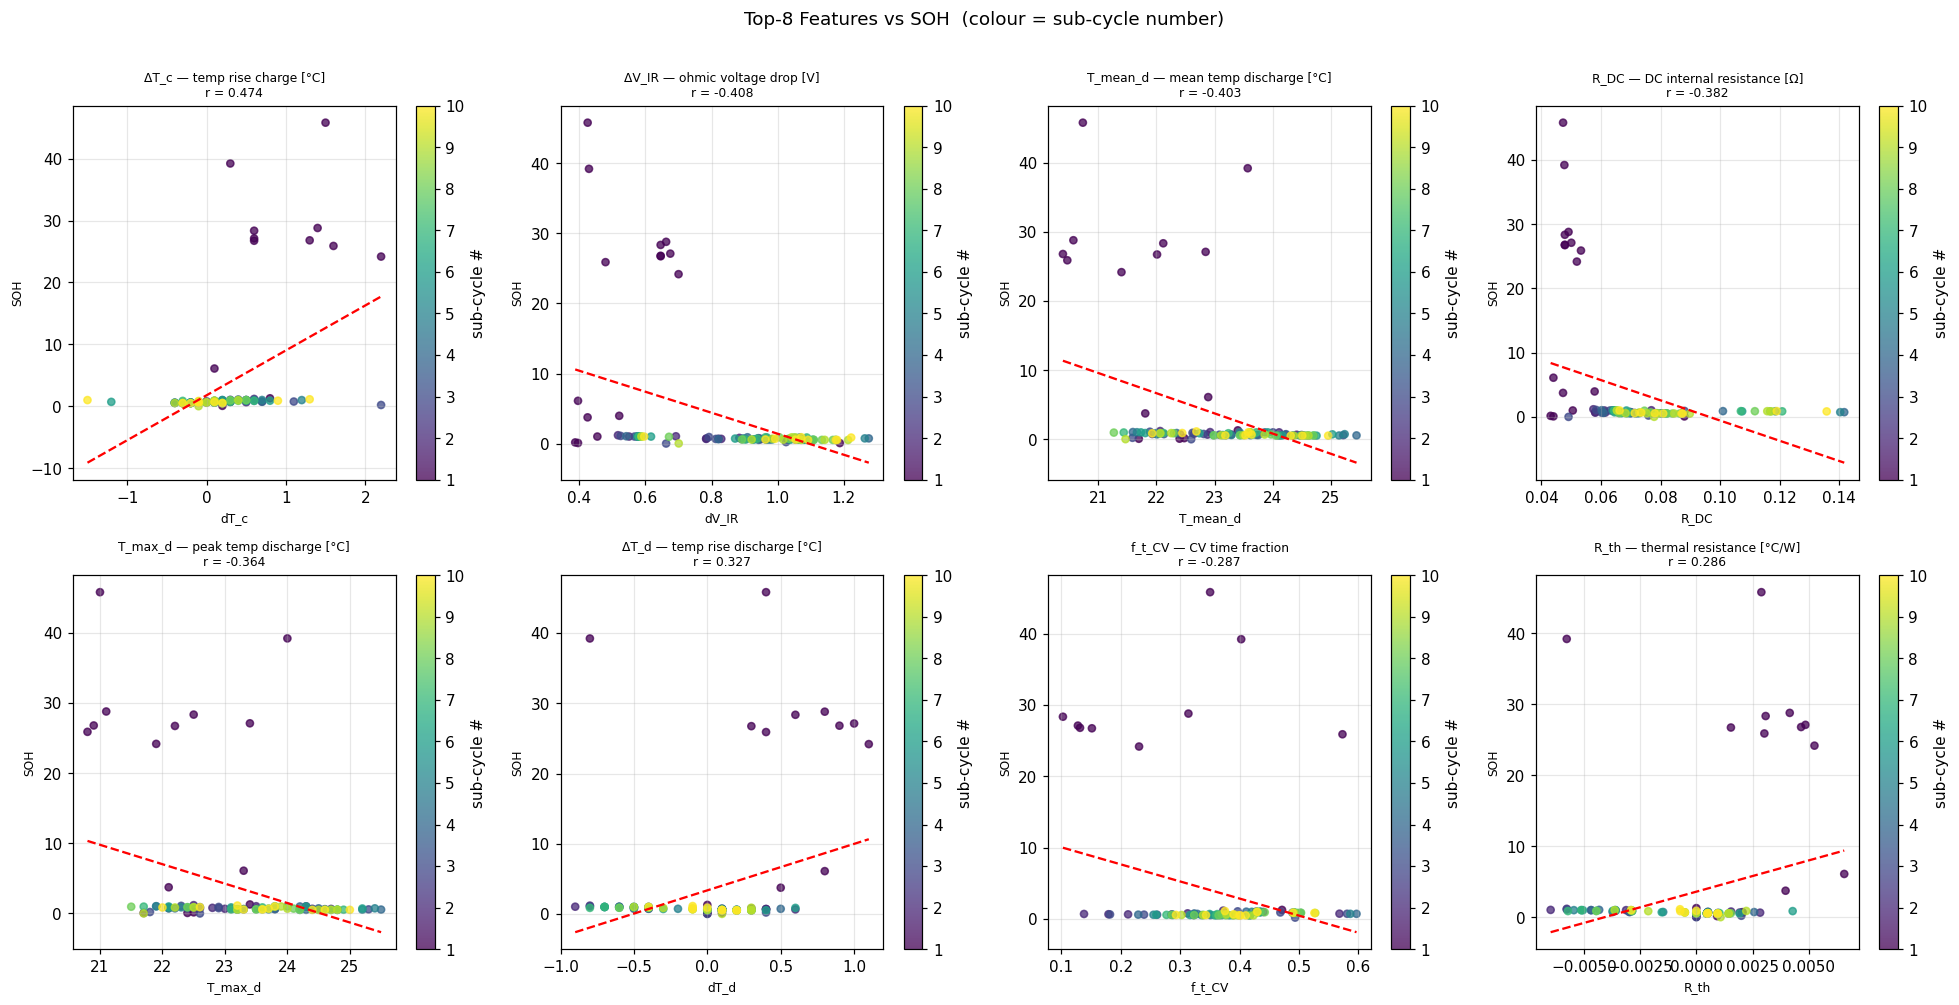

In [13]:
TOP_N  = 8
top_fs = corr_df.head(TOP_N)["Feature"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_fs):
    sub = merged[["SOH", col, "cycle_n"]].dropna()
    sc = ax.scatter(sub[col], sub["SOH"],
                    c=sub["cycle_n"], cmap="viridis", s=22, alpha=0.75)
    # Trend line
    z = np.polyfit(sub[col], sub["SOH"], 1)
    xs = np.linspace(sub[col].min(), sub[col].max(), 100)
    ax.plot(xs, np.polyval(z, xs), "r--", lw=1.5)
    r_val = corr_df.loc[corr_df["Feature"] == col, "Pearson r"].values[0]
    _, desc = FEAT_META.get(col, ("", col))
    ax.set_title(f"{desc}\nr = {r_val:.3f}", fontsize=8)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("SOH", fontsize=8)
    plt.colorbar(sc, ax=ax, label="sub-cycle #")

fig.suptitle("Top-8 Features vs SOH  (colour = sub-cycle number)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "feature_soh_scatter.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 11 · ICA degradation shift — all sessions, Cycle 01

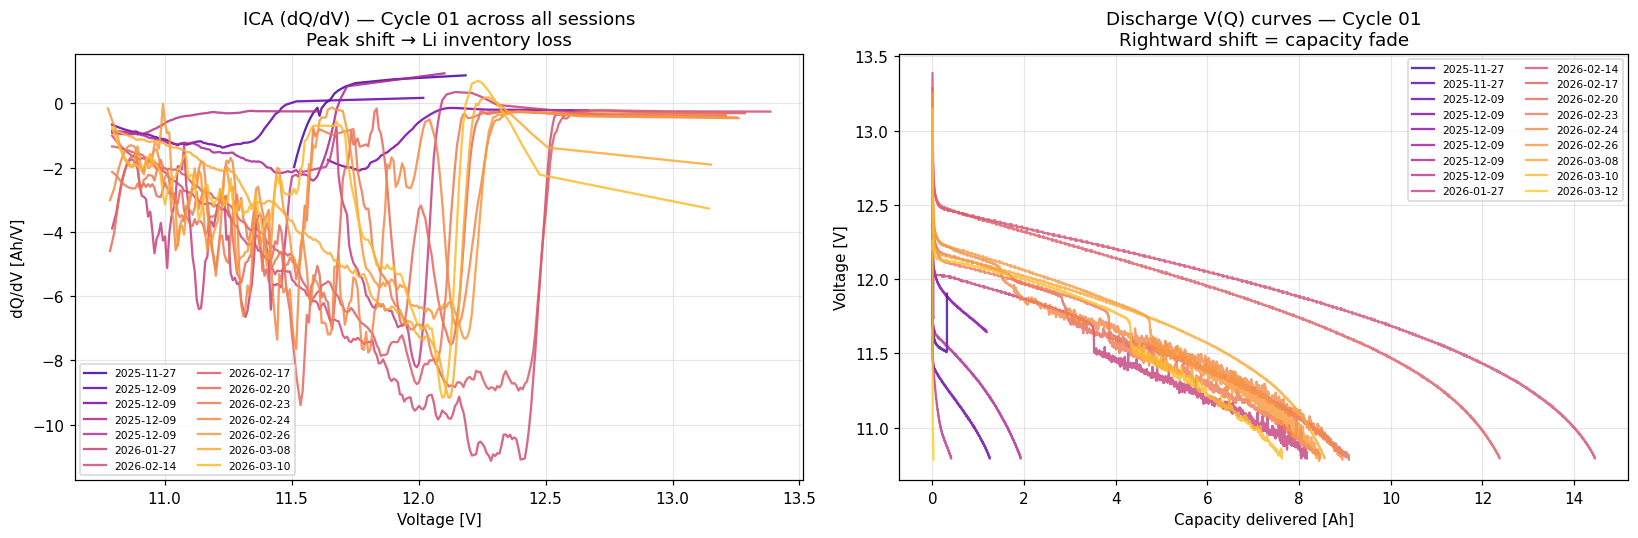

In [14]:
sessions_c01 = [s for s in SESSIONS
                if not load_discharge(s, 1).empty]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(sessions_c01)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: ICA curves ──────────────────────────────────────────────────────
ax = axes[0]
for sess, col in zip(sessions_c01, colors):
    df_d = load_discharge(sess, 1)
    if df_d.empty:
        continue
    v  = df_d["voltage"].to_numpy(float)
    i  = df_d["current"].to_numpy(float)
    t  = df_d["elapsed_s"].to_numpy(float)
    dt = _dt(t)
    q  = np.cumsum(np.abs(i) * dt) / 3600.0
    si = np.argsort(v)
    v_u, uidx = np.unique(v[si], return_index=True)
    q_u = q[si][uidx]
    if len(v_u) > ICA_SG_WIN:
        dv = float(np.mean(np.diff(v_u)))
        dqdv = savgol_filter(q_u, ICA_SG_WIN, ICA_SG_POLY, deriv=1, delta=dv)
        ax.plot(v_u, dqdv, color=col, alpha=0.85, label=sess[:10])
ax.set_xlabel("Voltage [V]")
ax.set_ylabel("dQ/dV [Ah/V]")
ax.set_title("ICA (dQ/dV) — Cycle 01 across all sessions\n"
             "Peak shift → Li inventory loss")
ax.legend(fontsize=7, ncol=2)

# ── Right: V(Q) curves ────────────────────────────────────────────────────
ax2 = axes[1]
for sess, col in zip(sessions_c01, colors):
    df_d = load_discharge(sess, 1)
    if df_d.empty:
        continue
    v  = df_d["voltage"].to_numpy(float)
    i  = df_d["current"].to_numpy(float)
    t  = df_d["elapsed_s"].to_numpy(float)
    dt = _dt(t)
    q  = np.cumsum(np.abs(i) * dt) / 3600.0
    ax2.plot(q, v, color=col, alpha=0.8, label=sess[:10])
ax2.set_xlabel("Capacity delivered [Ah]")
ax2.set_ylabel("Voltage [V]")
ax2.set_title("Discharge V(Q) curves — Cycle 01\n"
              "Rightward shift = capacity fade")
ax2.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "ica_degradation.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 12 · SOH trend over time and cumulative Ah

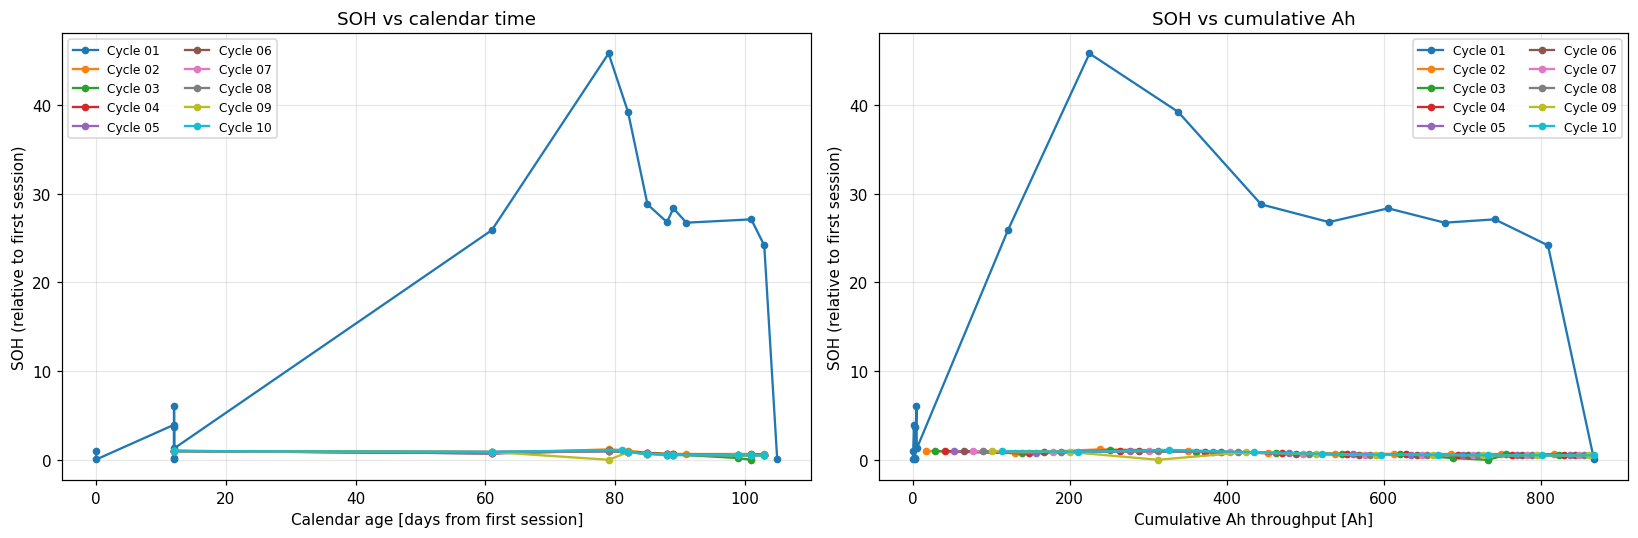

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for cn, grp in merged.groupby("cycle_n"):
    sub = grp.dropna(subset=["SOH", "t_cal"]).sort_values("t_cal")
    axes[0].plot(sub["t_cal"], sub["SOH"],
                 marker="o", ms=4, label=f"Cycle {cn:02d}")

axes[0].set_xlabel("Calendar age [days from first session]")
axes[0].set_ylabel("SOH (relative to first session)")
axes[0].set_title("SOH vs calendar time")
axes[0].legend(ncol=2, fontsize=8)

for cn, grp in merged.groupby("cycle_n"):
    sub = grp.dropna(subset=["SOH", "cumQ"]).sort_values("cumQ")
    axes[1].plot(sub["cumQ"], sub["SOH"],
                 marker="o", ms=4, label=f"Cycle {cn:02d}")

axes[1].set_xlabel("Cumulative Ah throughput [Ah]")
axes[1].set_ylabel("SOH (relative to first session)")
axes[1].set_title("SOH vs cumulative Ah")
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "soh_trend.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 13 · Feature correlation heatmap

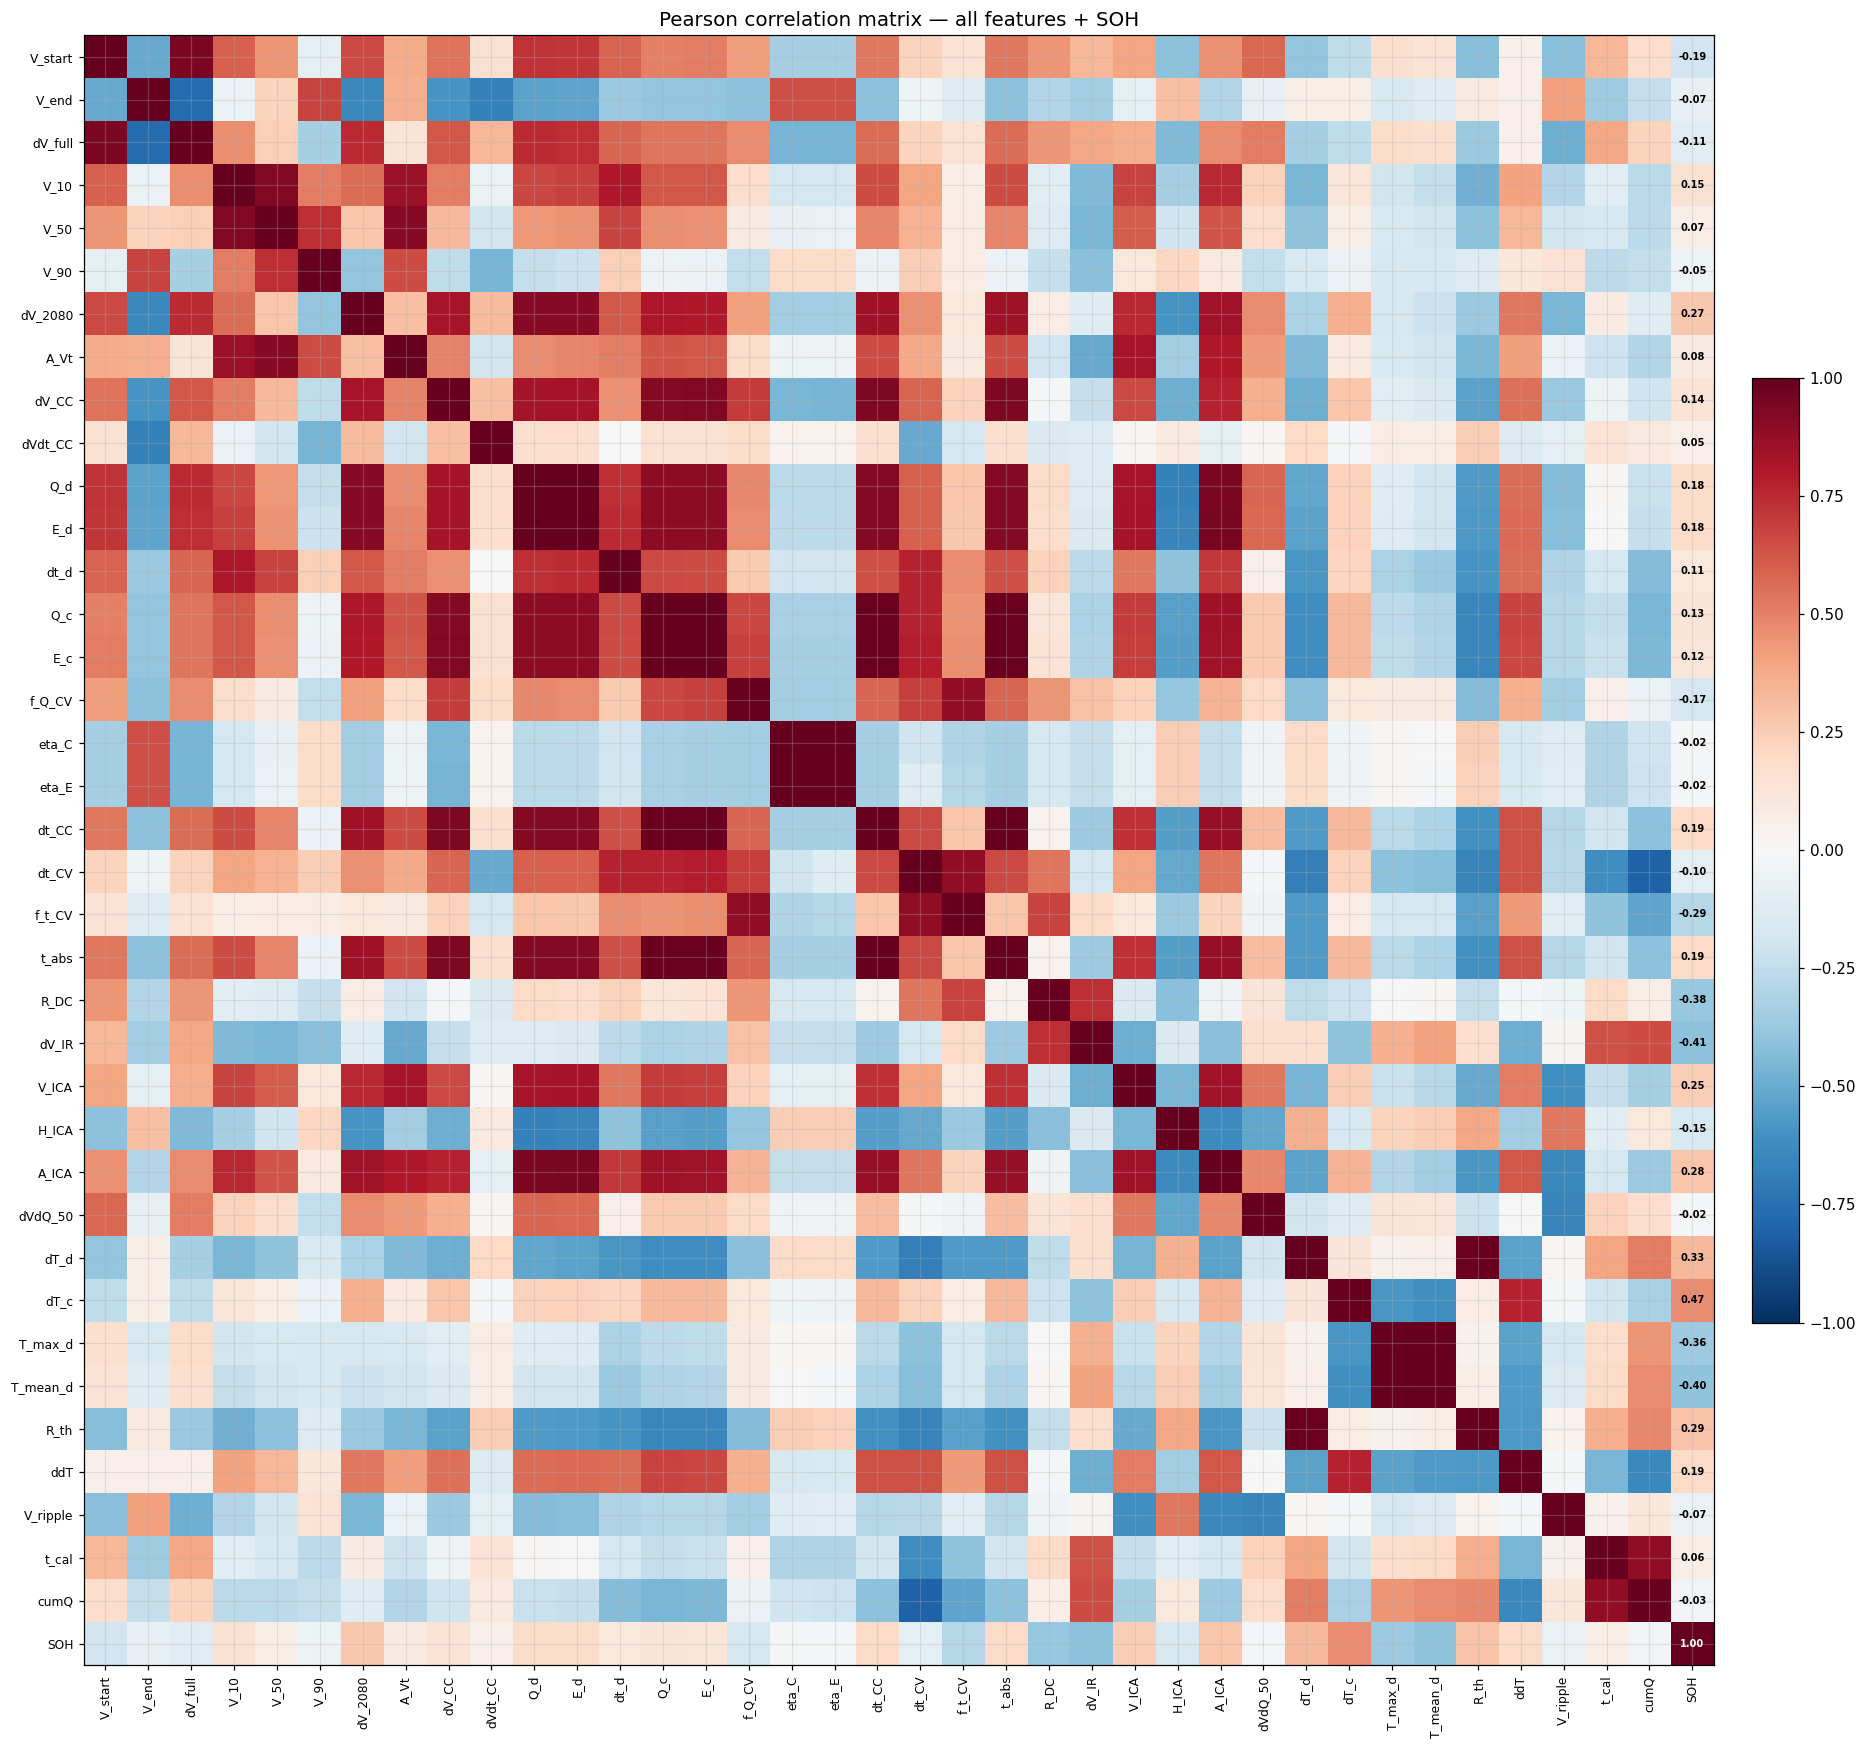

In [16]:
plot_cols = [c for c in feat_cols
             if c in merged.columns and merged[c].notna().sum() > 10]
corr_mat = merged[plot_cols + ["SOH"]].corr(method="pearson")

fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(corr_mat, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
ticks = range(len(corr_mat.columns))
ax.set_xticks(ticks); ax.set_xticklabels(corr_mat.columns,
                                          rotation=90, fontsize=8)
ax.set_yticks(ticks); ax.set_yticklabels(corr_mat.columns, fontsize=8)

# Annotate the SOH column
soh_col = list(corr_mat.columns).index("SOH")
for row_i, feat_name in enumerate(corr_mat.columns):
    val = corr_mat.iloc[row_i, soh_col]
    ax.text(soh_col, row_i, f"{val:.2f}", ha="center", va="center",
            fontsize=6.5, color="white" if abs(val) > 0.5 else "black",
            fontweight="bold")

ax.set_title("Pearson correlation matrix — all features + SOH", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "feature_correlation_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 14 · Export feature table

Saves the full feature matrix (with SOH) to CSV for downstream ML use.

In [17]:
out_path = os.path.join(BASE_DIR, "soh_features.csv")
export_cols = ["session_ts", "session_date", "t_cal", "cycle_n",
               "SOH", "SOH_nominal", "cumQ"] + feat_cols
export_cols = [c for c in export_cols if c in merged.columns]
merged[export_cols].to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {merged[export_cols].shape}")
merged[export_cols].describe().T

Saved: c:\Users\TPKam\Documents\BatPi_Download\soh_features.csv
Shape: (109, 44)


,count,mean,min,25%,50%,75%,max,std
session_date,109,2026-02-10 14:45:08.256880640,2025-11-27 00:00:00,2026-02-14 00:00:00,2026-02-20 00:00:00,2026-03-06 00:00:00,2026-03-12 00:00:00,NaN
t_cal,109.0,75.614679,0.0,79.0,85.0,99.0,105.0,30.325368
cycle_n,109.0,5.146789,1.0,2.0,5.0,8.0,10.0,3.011785
SOH,109.0,3.249446,0.000957,0.557954,0.710885,1.0,45.818144,8.425192
SOH_nominal,109.0,0.442179,0.000631,0.362918,0.431982,0.58718,0.802948,0.186709
cumQ,109.0,463.526394,0.315444,225.119285,505.162833,700.591,867.555736,273.466982
V_start,109.0,13.491839,11.6099,13.5269,13.5852,13.8186,14.0269,0.490237
V_end,109.0,10.85092,10.7598,10.7848,10.7931,10.7931,12.4517,0.263156
dV_full,109.0,2.640918,-0.1917,2.7338,2.7921,3.0255,3.2338,0.663656
V_10,109.0,12.0398,11.1265,11.91,11.985,12.1517,12.8851,0.270799
